In [66]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.multiclass import OneVsRestClassifier
from sklearn.model_selection import train_test_split
from sklearn.multiclass import OneVsRestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import average_precision_score
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score
from sklearn.metrics import hamming_loss
from sklearn.metrics import multilabel_confusion_matrix

In [41]:
df=pd.read_csv(r"C:\Users\Dhruv\Downloads\Share ai4i2020.csv")
df.head(5)

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [42]:
df['Type'].value_counts()

Type
L    5999
M    2996
H    1001
Name: count, dtype: int64

In [43]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  str    
 2   Type                     9996 non-null   str    
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dtypes: float64(3), int64(9), str(2)
me

In [44]:
df['Type']=df['Type'].fillna(df['Type'].mode()[0])

In [45]:
df.isnull().sum()

UDI                        0
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Machine failure            0
TWF                        0
HDF                        0
PWF                        0
OSF                        0
RNF                        0
dtype: int64

In [46]:
df[['TWF','HDF','PWF','OSF','RNF']].sum()

TWF     46
HDF    115
PWF     95
OSF     98
RNF     19
dtype: int64

In [47]:
df[['TWF','HDF','PWF','OSF','RNF']].sum(axis=1).value_counts()

0    9652
1     324
2      23
3       1
Name: count, dtype: int64

In [48]:
df[df[['TWF','HDF','PWF','OSF','RNF']].sum(axis=1) > 1][
    ['TWF','HDF','PWF','OSF','RNF']
]

,TWF,HDF,PWF,OSF,RNF
69,0,0,1,1,0
1324,0,0,1,1,0
1496,0,0,1,1,0
3611,1,0,0,0,1
3854,0,0,1,1,0
3943,0,0,1,1,0
4254,0,1,1,0,0
4342,0,1,1,0,0
4370,0,1,0,1,0
4383,0,1,0,1,0


In [49]:
df['Machine failure'].value_counts()

Machine failure
0    9661
1     339
Name: count, dtype: int64

In [50]:
df[
    (df['Machine failure'] == 1) &
    (df[['TWF','HDF','PWF','OSF','RNF']].sum(axis=1) == 0)
]

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
1437,1438,H30851,H,298.8,309.9,1439,45.2,40,1,0,0,0,0,0
2749,2750,M17609,M,299.7,309.2,1685,28.9,179,1,0,0,0,0,0
4044,4045,M18904,M,301.9,310.9,1419,47.7,20,1,0,0,0,0,0
4684,4685,M19544,M,303.6,311.8,1421,44.8,101,1,0,0,0,0,0
5536,5537,M20396,M,302.3,311.8,1363,54.0,119,1,0,0,0,0,0
5941,5942,L53121,L,300.6,310.7,1438,48.5,78,1,0,0,0,0,0
6478,6479,L53658,L,300.5,309.8,1663,29.1,145,1,0,0,0,0,0
8506,8507,L55686,L,298.4,309.6,1710,27.3,163,1,0,0,0,0,0
9015,9016,L56195,L,297.2,308.1,1431,49.7,210,1,0,0,0,0,0


In [51]:
df['Temperature_Difference'] = (
    df['Process temperature [K]'] -
    df['Air temperature [K]']
)

In [52]:
df['Power'] = (
    df['Torque [Nm]'] *
    (2 * np.pi * df['Rotational speed [rpm]'] / 60)
)

In [53]:
# Select Columns
x=df[['Type','Air temperature [K]','Process temperature [K]','Rotational speed [rpm]',
      'Torque [Nm]','Tool wear [min]','Temperature_Difference','Power']]
y=df[['TWF','HDF','PWF','OSF','RNF']]

In [54]:
x = pd.get_dummies(x, columns=['Type'], drop_first=True,dtype=int)

In [55]:
x.head(5)

,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Temperature_Difference,Power,Type_L,Type_M
0,298.1,308.6,1551,42.8,0,10.5,6951.590560,0,1
1,298.2,308.7,1408,46.3,3,10.5,6826.722724,1,0
2,298.1,308.5,1498,49.4,5,10.4,7749.387543,1,0
3,298.2,308.6,1433,39.5,7,10.4,5927.504659,1,0
4,298.2,308.7,1408,40.0,9,10.5,5897.816608,1,0


In [56]:
x.dtypes

Air temperature [K]        float64
Process temperature [K]    float64
Rotational speed [rpm]       int64
Torque [Nm]                float64
Tool wear [min]              int64
Temperature_Difference     float64
Power                      float64
Type_L                       int64
Type_M                       int64
dtype: object

In [61]:
x_train,x_test,y_train,y_test=train_test_split(x,y,
                                               test_size=0.3,
                                               random_state=42)

In [62]:
print(x.shape)
print(y.shape)

(10000, 9)
(10000, 5)


In [63]:
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(7000, 9)
(3000, 9)
(7000, 5)
(3000, 5)


In [64]:
# Model Logistic Regression
model_lr=OneVsRestClassifier(
    LogisticRegression(
        class_weight='balanced',
        max_iter=1000
    )
)
model_lr.fit(x_train,y_train)
y_pred_lr=model_lr.predict(x_test)

In [67]:
# Accuracy
accuracy=accuracy_score(y_test,y_pred_lr)
print("Accuracy Score:",accuracy)

Accuracy Score: 0.6346666666666667


In [68]:
# Classification Report
Report=classification_report(
    y_test,
    y_pred_lr,
    target_names=['TWF','HDF','PWF','OSF','RNF'],
    zero_division=0
)
print("Logistic Regression Classification Report:",Report)

Logistic Regression Classification Report:               precision    recall  f1-score   support

         TWF       0.05      0.86      0.09        14
         HDF       0.26      1.00      0.42        25
         PWF       0.35      1.00      0.52        31
         OSF       0.60      1.00      0.75        28
         RNF       0.00      0.29      0.00         7

   micro avg       0.07      0.93      0.13       105
   macro avg       0.25      0.83      0.36       105
weighted avg       0.33      0.93      0.46       105
 samples avg       0.02      0.03      0.02       105



In [70]:
# Calculate individual failure PR-AUC Curve
y_prob_lr = model_lr.predict_proba(x_test)
for i,label in enumerate(['TWF','HDF','PWF','OSF','RNF']):
    score=average_precision_score(y_test.iloc[:,i],y_prob_lr[:,i])
    print(label,"PR-AUC:",score)

TWF PR-AUC: 0.13839468800770677
HDF PR-AUC: 0.7924549119889852
PWF PR-AUC: 0.7794753358717951
OSF PR-AUC: 0.9441790812647803
RNF PR-AUC: 0.003024616721752713


In [71]:
# Hamming Loss
haming_lr=hamming_loss(y_test,y_pred_lr)
print("Logistic Hamming Loss:",haming_lr)

Logistic Hamming Loss: 0.08593333333333333


In [82]:
for i, label in enumerate(['TWF','HDF','PWF','OSF','RNF']):
    importance = abs(model_lr.estimators_[i].coef_[0])

    feature_importance = pd.Series(
        importance,
        index=x_train.columns
    ).sort_values(ascending=False)

    print("\n", label)
    print(feature_importance.head(5))


 TWF
Type_L                    1.070342
Type_M                    0.674898
Torque [Nm]               0.432660
Temperature_Difference    0.277438
Tool wear [min]           0.178837
dtype: float64

 HDF
Temperature_Difference     4.713649
Torque [Nm]                3.274685
Air temperature [K]        2.865984
Process temperature [K]    1.847665
Rotational speed [rpm]     0.181986
dtype: float64

 PWF
Type_L                    1.393510
Type_M                    1.022371
Torque [Nm]               1.005074
Air temperature [K]       0.256001
Temperature_Difference    0.141452
dtype: float64

 OSF
Type_L                    4.458172
Type_M                    3.867759
Torque [Nm]               1.998344
Tool wear [min]           0.485022
Temperature_Difference    0.155175
dtype: float64

 RNF
Type_M                     3.125248
Type_L                     2.079191
Torque [Nm]                0.410429
Air temperature [K]        0.031762
Process temperature [K]    0.028632
dtype: float64


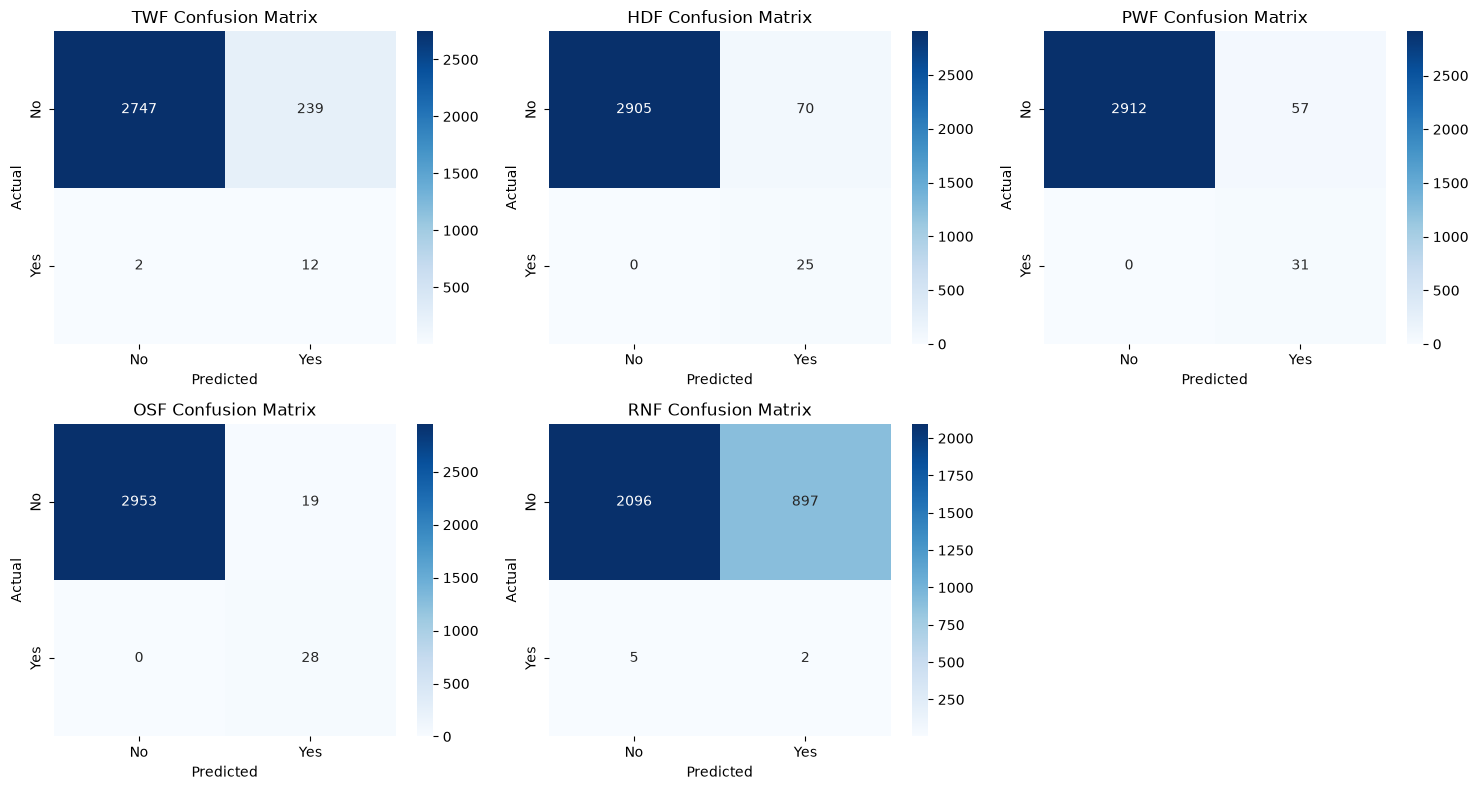

In [114]:
# Confusion Matrix
labels = ['TWF','HDF','PWF','OSF','RNF']
cm_lr = multilabel_confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(15, 8))
for i, label in enumerate(labels):
    plt.subplot(2, 3, i + 1)
    
    sns.heatmap(
        cm[i],
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=['No', 'Yes'],
        yticklabels=['No', 'Yes']
    )
    
    plt.title(f'{label} Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')

plt.tight_layout()
plt.show()

In [94]:
# Calculating thresold
y_prob_lr = model_lr.predict_proba(x_test)
from sklearn.metrics import precision_score, recall_score, f1_score

labels = ['TWF','HDF','PWF','OSF','RNF']
thresholds = [0.1, 0.2, 0.3, 0.4, 0.5]

for i, label in enumerate(labels):
    print("\n", label)

    for threshold in thresholds:
        y_pred = (y_prob_lr[:, i] >= threshold).astype(int)

        precision = precision_score(
            y_test.iloc[:, i],
            y_pred,
            zero_division=0
        )

        recall = recall_score(
            y_test.iloc[:, i],
            y_pred,
            zero_division=0
        )

        f1 = f1_score(
            y_test.iloc[:, i],
            y_pred,
            zero_division=0
        )

        print(
            "Threshold:", threshold,
            "Precision:", round(precision, 2),
            "Recall:", round(recall, 2),
            "F1:", round(f1, 2)
        )


 TWF
Threshold: 0.1 Precision: 0.03 Recall: 1.0 F1: 0.06
Threshold: 0.2 Precision: 0.04 Recall: 1.0 F1: 0.07
Threshold: 0.3 Precision: 0.04 Recall: 0.93 F1: 0.08
Threshold: 0.4 Precision: 0.04 Recall: 0.93 F1: 0.08
Threshold: 0.5 Precision: 0.05 Recall: 0.86 F1: 0.09

 HDF
Threshold: 0.1 Precision: 0.16 Recall: 1.0 F1: 0.28
Threshold: 0.2 Precision: 0.19 Recall: 1.0 F1: 0.32
Threshold: 0.3 Precision: 0.22 Recall: 1.0 F1: 0.36
Threshold: 0.4 Precision: 0.25 Recall: 1.0 F1: 0.39
Threshold: 0.5 Precision: 0.26 Recall: 1.0 F1: 0.42

 PWF
Threshold: 0.1 Precision: 0.19 Recall: 1.0 F1: 0.31
Threshold: 0.2 Precision: 0.23 Recall: 1.0 F1: 0.37
Threshold: 0.3 Precision: 0.28 Recall: 1.0 F1: 0.44
Threshold: 0.4 Precision: 0.32 Recall: 1.0 F1: 0.48
Threshold: 0.5 Precision: 0.35 Recall: 1.0 F1: 0.52

 OSF
Threshold: 0.1 Precision: 0.52 Recall: 1.0 F1: 0.68
Threshold: 0.2 Precision: 0.55 Recall: 1.0 F1: 0.71
Threshold: 0.3 Precision: 0.56 Recall: 1.0 F1: 0.72
Threshold: 0.4 Precision: 0.57 Recall

In [ ]:
# Random Forest Classifier




In [95]:
# Model Random Forest classifier & prediction
model_rf=OneVsRestClassifier(
    RandomForestClassifier(
        n_estimators=650,
        class_weight='balanced',
        random_state=42
    )
)
model_rf.fit(x_train,y_train)
y_pred_rf=model_rf.predict(x_test)

In [96]:
# Probablities
y_prob_rf=model_rf.predict_proba(x_test)
print(y_prob_rf)

[[0.02153846 0.         0.         0.         0.        ]
 [0.         0.00769231 0.         0.         0.        ]
 [0.         0.         0.         0.         0.        ]
 ...
 [0.         0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.00615385]
 [0.         0.         0.         0.         0.00153846]]


In [97]:
# Classification Report
random_report=classification_report(
    y_test,
    y_pred_rf,
    target_names=['TWF','HDF','PWF','ODF','RNF'],
    zero_division=0
)
print("Random Forest Classification Report:",random_report)

Random Forest Classification Report:               precision    recall  f1-score   support

         TWF       0.20      0.07      0.11        14
         HDF       0.85      0.92      0.88        25
         PWF       1.00      1.00      1.00        31
         ODF       0.83      0.71      0.77        28
         RNF       0.00      0.00      0.00         7

   micro avg       0.86      0.71      0.78       105
   macro avg       0.58      0.54      0.55       105
weighted avg       0.75      0.71      0.73       105
 samples avg       0.02      0.02      0.02       105



In [98]:
# Calculating individual Failure PR-AUC
for i, label in enumerate(['TWF','HDF','PWF','OSF','RNF']):
    score = average_precision_score(
        y_test.iloc[:, i],
        y_prob_rf[:, i]
    )
    print(label, "PR-AUC:", score)

TWF PR-AUC: 0.12657990711145334
HDF PR-AUC: 0.9847701149425288
PWF PR-AUC: 1.0
OSF PR-AUC: 0.8790538877407211
RNF PR-AUC: 0.020222377459541273


In [99]:
# Hamming loss
haming_rf=hamming_loss(y_test,y_pred_rf)
print("Random forest Hamming Loss:",haming_rf)

Random forest Hamming Loss: 0.0028


In [100]:
# Feature Importance
for i, label in enumerate(['TWF','HDF','PWF','OSF','RNF']):
    importance = model_rf.estimators_[i].feature_importances_

    feature_importance = pd.Series(
        importance,
        index=x_train.columns
    ).sort_values(ascending=False)

    print("\n", label)
    print(feature_importance.head(5))


 TWF
Tool wear [min]           0.755460
Power                     0.066224
Torque [Nm]               0.046164
Rotational speed [rpm]    0.033676
Air temperature [K]       0.032925
dtype: float64

 HDF
Temperature_Difference    0.389881
Rotational speed [rpm]    0.307728
Air temperature [K]       0.147873
Torque [Nm]               0.085462
Power                     0.039685
dtype: float64

 PWF
Power                      0.489737
Torque [Nm]                0.330495
Rotational speed [rpm]     0.160807
Tool wear [min]            0.007802
Process temperature [K]    0.004343
dtype: float64

 OSF
Tool wear [min]           0.438509
Torque [Nm]               0.250422
Power                     0.186586
Rotational speed [rpm]    0.089838
Type_L                    0.015864
dtype: float64

 RNF
Torque [Nm]                0.196451
Power                      0.184406
Temperature_Difference     0.160343
Rotational speed [rpm]     0.136362
Process temperature [K]    0.099157
dtype: float64


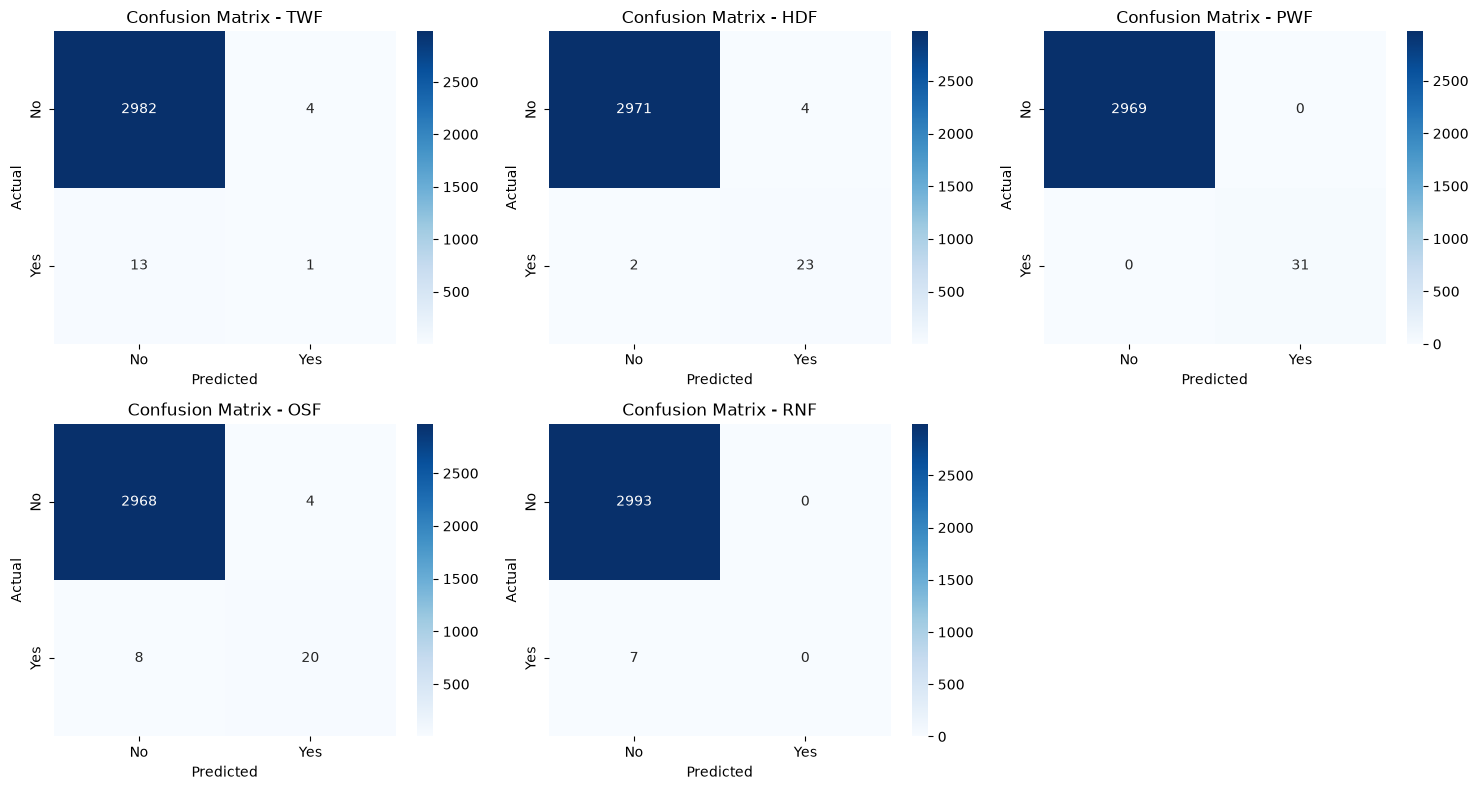

In [108]:
# Confusion Matrix
cm_rf = multilabel_confusion_matrix(y_test, y_pred_rf)

labels = ['TWF', 'HDF', 'PWF', 'OSF', 'RNF']

plt.figure(figsize=(15,8))
for i, label in enumerate(labels):
    plt.subplot(2, 3, i + 1)
    sns.heatmap(
        cm_rf[i],
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=['No', 'Yes'],
        yticklabels=['No', 'Yes']
    )
    
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title(f'Confusion Matrix - {label}')
plt.tight_layout()    
plt.show()

In [115]:
# Understanding Bussiness
for i, label in enumerate(['TWF','HDF','PWF','OSF','RNF']):
    tn, fp, fn, tp = cm[i].ravel()

    print(
        label,
        "TP:", tp,
        "FP:", fp,
        "FN:", fn,
        "TN:", tn
    )

TWF TP: 12 FP: 239 FN: 2 TN: 2747
HDF TP: 25 FP: 70 FN: 0 TN: 2905
PWF TP: 31 FP: 57 FN: 0 TN: 2912
OSF TP: 28 FP: 19 FN: 0 TN: 2953
RNF TP: 2 FP: 897 FN: 5 TN: 2096


In [103]:
# Threshold turning for random Forest
y_prob_rf = model_rf.predict_proba(x_test)

labels = ['TWF','HDF','PWF','OSF','RNF']
thresholds = [0.1, 0.2, 0.3, 0.4, 0.5]

for i, label in enumerate(labels):
    print("\n", label)

    for threshold in thresholds:
        y_pred = (y_prob_rf[:, i] >= threshold).astype(int)

        precision = precision_score(
            y_test.iloc[:, i],
            y_pred,
            zero_division=0
        )

        recall = recall_score(
            y_test.iloc[:, i],
            y_pred,
            zero_division=0
        )

        f1 = f1_score(
            y_test.iloc[:, i],
            y_pred,
            zero_division=0
        )

        print(
            "Threshold:", threshold,
            "Precision:", round(precision, 2),
            "Recall:", round(recall, 2),
            "F1:", round(f1, 2)
        )


 TWF
Threshold: 0.1 Precision: 0.07 Recall: 0.5 F1: 0.12
Threshold: 0.2 Precision: 0.06 Recall: 0.21 F1: 0.1
Threshold: 0.3 Precision: 0.05 Recall: 0.07 F1: 0.06
Threshold: 0.4 Precision: 0.11 Recall: 0.07 F1: 0.09
Threshold: 0.5 Precision: 0.2 Recall: 0.07 F1: 0.11

 HDF
Threshold: 0.1 Precision: 0.83 Recall: 1.0 F1: 0.91
Threshold: 0.2 Precision: 0.83 Recall: 1.0 F1: 0.91
Threshold: 0.3 Precision: 0.83 Recall: 1.0 F1: 0.91
Threshold: 0.4 Precision: 0.83 Recall: 0.96 F1: 0.89
Threshold: 0.5 Precision: 0.85 Recall: 0.92 F1: 0.88

 PWF
Threshold: 0.1 Precision: 0.94 Recall: 1.0 F1: 0.97
Threshold: 0.2 Precision: 0.97 Recall: 1.0 F1: 0.98
Threshold: 0.3 Precision: 1.0 Recall: 1.0 F1: 1.0
Threshold: 0.4 Precision: 1.0 Recall: 1.0 F1: 1.0
Threshold: 0.5 Precision: 1.0 Recall: 1.0 F1: 1.0

 OSF
Threshold: 0.1 Precision: 0.48 Recall: 0.89 F1: 0.62
Threshold: 0.2 Precision: 0.54 Recall: 0.89 F1: 0.68
Threshold: 0.3 Precision: 0.63 Recall: 0.86 F1: 0.73
Threshold: 0.4 Precision: 0.76 Recall: 

In [ ]:
# conclusion
# The model is designed as an early-warning system rather than an accuracy-maximizing classifier. Thresholds were adjusted to prioritize recall 
# because a missed machine failure can result in unplanned downtime, while a false alarm primarily creates an additional inspection or maintenance check.